In [1]:
# ─────────────────────────────────────────────────────────────
# CELL 1 — Install dependencies
# ─────────────────────────────────────────────────────────────
!pip install -q xgboost scikit-learn pandas numpy joblib matplotlib seaborn
print('✅ All packages installed')

✅ All packages installed


In [2]:
# ─────────────────────────────────────────────────────────────
# CELL 2 — Upload CSV
# ─────────────────────────────────────────────────────────────
from google.colab import files

print('📂 Upload your model3_congestion_scorer.csv file:')
uploaded = files.upload()

import os
CSV_PATH = list(uploaded.keys())[0]
print(f'✅ Uploaded: {CSV_PATH}')

📂 Upload your model3_congestion_scorer.csv file:


Saving model3_congestion_scorer.csv to model3_congestion_scorer.csv
✅ Uploaded: model3_congestion_scorer.csv


In [3]:
# ─────────────────────────────────────────────────────────────
# CELL 3 — Imports & Constants
# ─────────────────────────────────────────────────────────────
import warnings, time, os
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import joblib

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import (GradientBoostingClassifier, GradientBoostingRegressor,
                               RandomForestClassifier, RandomForestRegressor)
from sklearn.metrics import (classification_report, confusion_matrix,
                              f1_score, mean_absolute_error,
                              mean_squared_error, r2_score)
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from xgboost import XGBClassifier, XGBRegressor

RISK_LABEL_ORDER = ['LOW', 'MEDIUM', 'HIGH', 'CRITICAL']

VIOLATION_FLAGS = [
    'vt_no_parking', 'vt_wrong_parking', 'vt_parking_in_a_main_road',
    'vt_parking_near_road_crossing', 'vt_parking_on_footpath',
    'vt_double_parking', 'vt_parking_near_bustop_school_hospital_etc',
]

CATEGORICAL_COLS = ['time_period', 'vehicle_category']

# NOTE: h3_total_violations / h3_hour_density intentionally NOT listed here.
# They're still computed in feature engineering and feed log_h3_total_violations /
# log_h3_hour_density (in ENGINEERED_COLS) plus density_ratio. Including both the raw
# AND log versions double-weighted the violation-count signal and biased predictions
# toward HIGH/CRITICAL everywhere. Keep only the log-transformed versions.
NUMERIC_COLS = [
    'hour', 'day_of_week', 'month', 'is_weekend', 'at_junction',
    'vehicle_weight', 'junction_importance', 'station_density',
    'violation_count', 'offence_code_count',
] + VIOLATION_FLAGS

ENGINEERED_COLS = [
    'violation_type_count', 'weighted_severity', 'junction_vehicle_interaction',
    'density_ratio', 'is_peak_hour', 'is_night',
    'log_h3_total_violations', 'log_h3_hour_density',
]

ALL_NUMERIC = NUMERIC_COLS + ENGINEERED_COLS

print('✅ Constants loaded')

✅ Constants loaded


In [4]:
# ─────────────────────────────────────────────────────────────
# CELL 4 — Load & Validate Data
# ─────────────────────────────────────────────────────────────
df_raw = pd.read_csv(CSV_PATH)
print(f'Raw shape : {df_raw.shape}')

# Drop null targets
df = df_raw.dropna(subset=['congestion_impact_score', 'congestion_risk_level'])
df = df[df['congestion_risk_level'].isin(RISK_LABEL_ORDER)].copy()
print(f'Clean shape: {df.shape}')

# Class distribution
dist = df['congestion_risk_level'].value_counts()
print('\nRisk Level Distribution:')
for lbl in RISK_LABEL_ORDER:
    c = dist.get(lbl, 0)
    print(f'  {lbl:<10}: {c:>7,}  ({100*c/len(df):.1f}%)')

# Quick stats
print(f'\ncongestion_impact_score — min={df["congestion_impact_score"].min():.2f}  '
      f'max={df["congestion_impact_score"].max():.2f}  '
      f'mean={df["congestion_impact_score"].mean():.2f}')

Raw shape : (291945, 24)
Clean shape: (291945, 24)

Risk Level Distribution:
  LOW       : 145,972  (50.0%)
  MEDIUM    :  72,986  (25.0%)
  HIGH      :  43,792  (15.0%)
  CRITICAL  :  29,195  (10.0%)

congestion_impact_score — min=2.17  max=20.52  mean=4.15


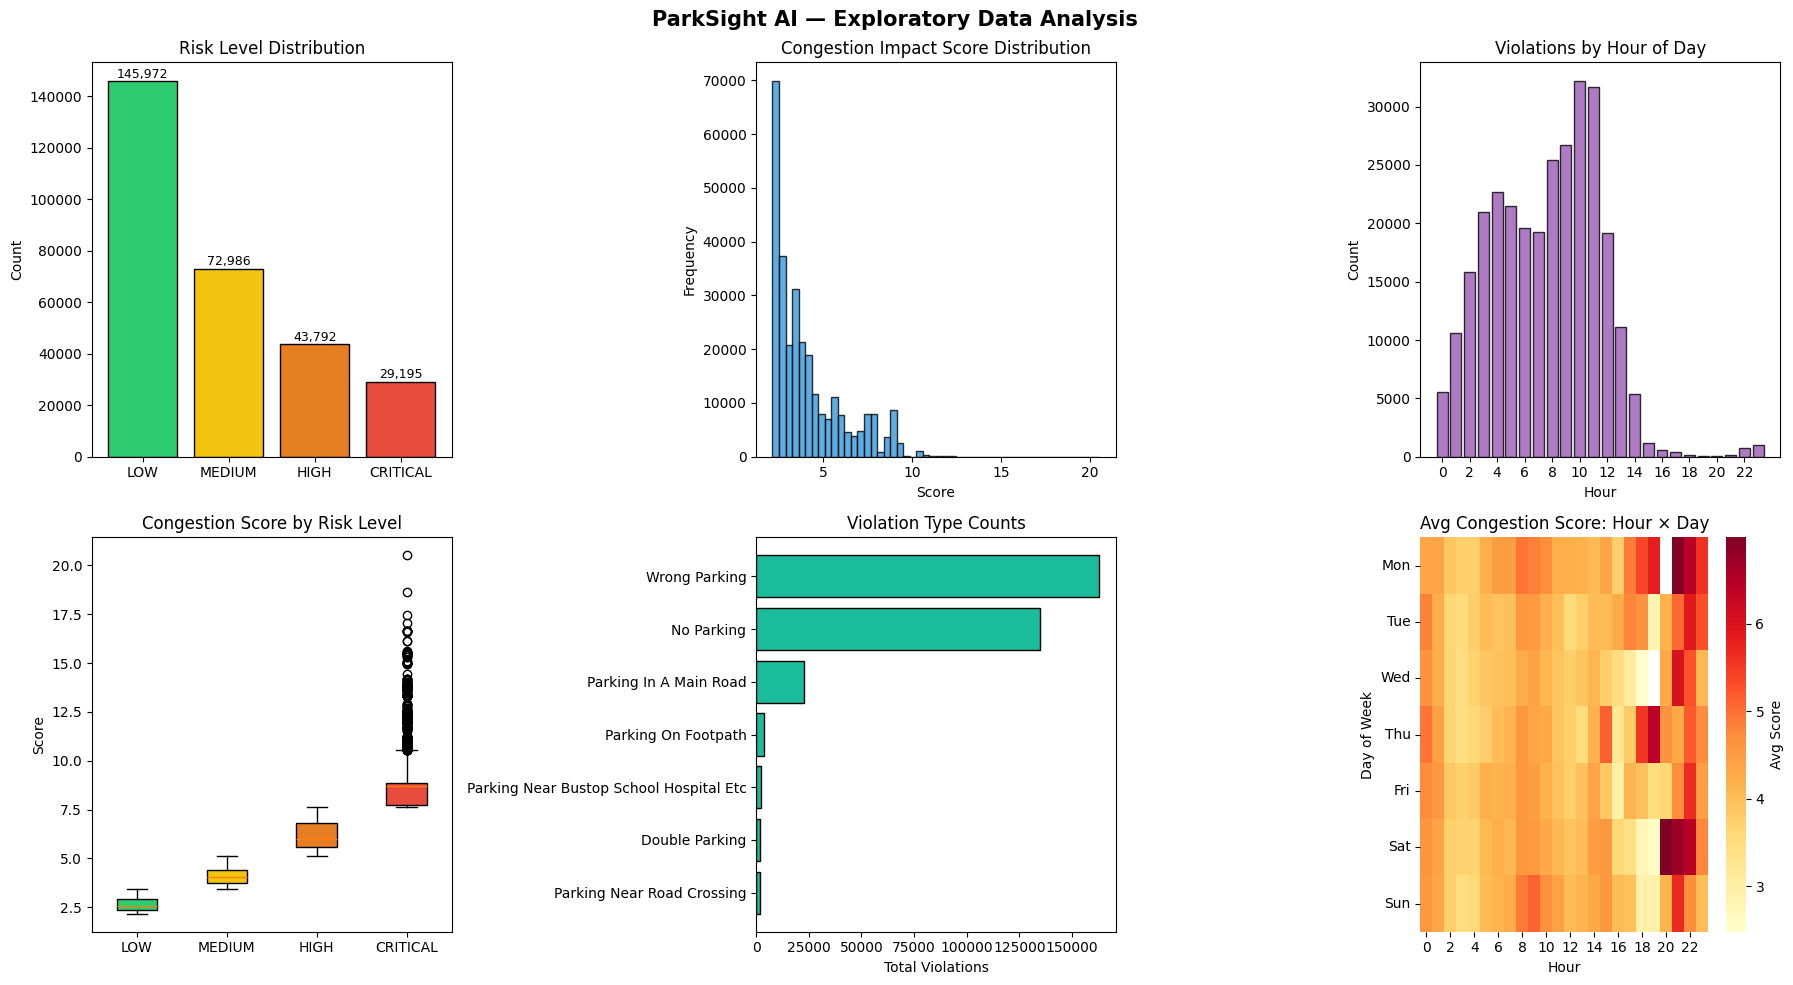

✅ EDA complete


In [5]:
# ─────────────────────────────────────────────────────────────
# CELL 5 — EDA Plots
# ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('ParkSight AI — Exploratory Data Analysis', fontsize=15, fontweight='bold')

colors = {'LOW':'#2ecc71','MEDIUM':'#f1c40f','HIGH':'#e67e22','CRITICAL':'#e74c3c'}

# 1. Risk level distribution
ax = axes[0, 0]
counts = [dist.get(l, 0) for l in RISK_LABEL_ORDER]
bars = ax.bar(RISK_LABEL_ORDER, counts, color=[colors[l] for l in RISK_LABEL_ORDER], edgecolor='black')
ax.set_title('Risk Level Distribution')
ax.set_ylabel('Count')
for bar, c in zip(bars, counts):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+200, f'{c:,}',
            ha='center', va='bottom', fontsize=9)

# 2. Congestion score distribution
ax = axes[0, 1]
ax.hist(df['congestion_impact_score'], bins=50, color='#3498db', edgecolor='black', alpha=0.8)
ax.set_title('Congestion Impact Score Distribution')
ax.set_xlabel('Score'); ax.set_ylabel('Frequency')

# 3. Violations by hour
ax = axes[0, 2]
hourly = df.groupby('hour').size()
ax.bar(hourly.index, hourly.values, color='#9b59b6', edgecolor='black', alpha=0.8)
ax.set_title('Violations by Hour of Day')
ax.set_xlabel('Hour'); ax.set_ylabel('Count')
ax.set_xticks(range(0, 24, 2))

# 4. Score by risk level (box plot)
ax = axes[1, 0]
data_by_risk = [df[df['congestion_risk_level']==l]['congestion_impact_score'].values
                for l in RISK_LABEL_ORDER]
bp = ax.boxplot(data_by_risk, labels=RISK_LABEL_ORDER, patch_artist=True)
for patch, lbl in zip(bp['boxes'], RISK_LABEL_ORDER):
    patch.set_facecolor(colors[lbl])
ax.set_title('Congestion Score by Risk Level')
ax.set_ylabel('Score')

# 5. Violation type breakdown
ax = axes[1, 1]
vt_totals = df[VIOLATION_FLAGS].sum().sort_values(ascending=True)
short_names = [v.replace('vt_','').replace('_',' ').title() for v in vt_totals.index]
ax.barh(short_names, vt_totals.values, color='#1abc9c', edgecolor='black')
ax.set_title('Violation Type Counts')
ax.set_xlabel('Total Violations')

# 6. Heatmap: hour vs day_of_week
ax = axes[1, 2]
pivot = df.pivot_table(values='congestion_impact_score',
                        index='day_of_week', columns='hour', aggfunc='mean')
sns.heatmap(pivot, ax=ax, cmap='YlOrRd', cbar_kws={'label': 'Avg Score'})
ax.set_title('Avg Congestion Score: Hour × Day')
ax.set_xlabel('Hour'); ax.set_ylabel('Day of Week')
ax.set_yticklabels(['Mon','Tue','Wed','Thu','Fri','Sat','Sun'], rotation=0)

plt.tight_layout()
plt.savefig('eda_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ EDA complete')

In [6]:
# ─────────────────────────────────────────────────────────────
# CELL 6 — Feature Engineering
# ─────────────────────────────────────────────────────────────
PEAK_HOURS  = [7,8,9,10,17,18,19,20]
NIGHT_HOURS = [22,23,0,1,2,3,4,5]
assert not set(PEAK_HOURS) & set(NIGHT_HOURS), 'is_peak_hour and is_night hour sets must not overlap'

def engineer_features(df):
    df = df.copy()
    df['violation_type_count']          = df[VIOLATION_FLAGS].sum(axis=1)
    df['junction_vehicle_interaction']  = df['at_junction'] * df['vehicle_weight']
    df['is_peak_hour']                  = df['hour'].isin(PEAK_HOURS).astype(int)
    df['is_night']                      = df['hour'].isin(NIGHT_HOURS).astype(int)

    # Force a consistent night bucket so the categorical time_period feature can't
    # silently carry an upstream "late hour == high activity" mapping from the raw CSV.
    df.loc[df['is_night'] == 1, 'time_period'] = 'late_night'

    df['weighted_severity']             = (
        df['vt_parking_in_a_main_road']                    * 2.0 +
        df['vt_double_parking']                            * 1.8 +
        df['vt_parking_near_road_crossing']                * 1.5 +
        df['vt_parking_near_bustop_school_hospital_etc']   * 1.3 +
        df['vt_wrong_parking']                             * 1.0 +
        df['vt_no_parking']                                * 0.8 +
        df['vt_parking_on_footpath']                       * 0.6
    )
    # Discount severity at night: fewer pedestrians/cross-traffic exposed to the violation.
    df.loc[df['is_night'] == 1, 'weighted_severity'] *= 0.5

    # density_ratio: guard against inf/NaN, then log1p to tame outliers (same treatment
    # already applied to h3_total_violations / h3_hour_density below).
    density_ratio = df['h3_hour_density'] / (df['h3_total_violations'] + 1)
    density_ratio = density_ratio.replace([np.inf, -np.inf], 0).fillna(0)
    df['density_ratio']                 = np.log1p(density_ratio)

    df['log_h3_total_violations']       = np.log1p(df['h3_total_violations'])
    df['log_h3_hour_density']           = np.log1p(df['h3_hour_density'])
    return df

df = engineer_features(df)

X = df[ALL_NUMERIC + CATEGORICAL_COLS]

# Regression target
y_reg = df['congestion_impact_score'].values

# Classification target
le = LabelEncoder()
le.classes_ = np.array(RISK_LABEL_ORDER)
y_cls = le.transform(df['congestion_risk_level'].values)

# Class weights for imbalance
class_counts = np.bincount(y_cls)
class_weights = {i: len(y_cls)/(len(RISK_LABEL_ORDER)*c) for i,c in enumerate(class_counts)}
print('Class weights:', dict(zip(RISK_LABEL_ORDER, [round(v,2) for v in class_weights.values()])))

# Train/test split
X_train, X_test, yr_train, yr_test, yc_train, yc_test = train_test_split(
    X, y_reg, y_cls, test_size=0.2, random_state=42, stratify=y_cls
)
print(f'\nTrain: {len(X_train):,}  |  Test: {len(X_test):,}')
print('✅ Features ready')

Class weights: {'LOW': np.float64(0.5), 'MEDIUM': np.float64(1.0), 'HIGH': np.float64(1.67), 'CRITICAL': np.float64(2.5)}

Train: 233,556  |  Test: 58,389
✅ Features ready


In [7]:
# ─────────────────────────────────────────────────────────────
# CELL 7 — Pipeline Builder
# ─────────────────────────────────────────────────────────────
def build_pipeline(model):
    preprocessor = ColumnTransformer([
        ('num', StandardScaler(), ALL_NUMERIC),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), CATEGORICAL_COLS),
    ], remainder='drop')
    return Pipeline([('preprocessor', preprocessor), ('model', model)])

# GradientBoosting (sklearn) dropped: it's single-threaded (no n_jobs), was the
# slowest model by far, and XGBoost already covers the same gradient-boosted-tree
# family with multicore training -- this alone is most of the 45min -> faster runtime.
MODEL_CONFIGS = {
    'xgboost': {
        'regressor':  XGBRegressor(
            n_estimators=400, max_depth=6, learning_rate=0.05,
            subsample=0.8, colsample_bytree=0.8,
            reg_alpha=0.1, reg_lambda=1.0, min_child_weight=5,
            random_state=42, n_jobs=-1, verbosity=0, eval_metric='rmse'),
        'classifier': XGBClassifier(
            n_estimators=400, max_depth=6, learning_rate=0.05,
            subsample=0.8, colsample_bytree=0.8,
            reg_alpha=0.1, reg_lambda=1.0, min_child_weight=5,
            use_label_encoder=False, random_state=42, n_jobs=-1,
            verbosity=0, eval_metric='mlogloss'),
    },
    'random_forest': {
        'regressor':  RandomForestRegressor(
            n_estimators=300, max_depth=15, min_samples_leaf=5,
            max_features='sqrt', random_state=42, n_jobs=-1),
        'classifier': RandomForestClassifier(
            n_estimators=300, max_depth=15, min_samples_leaf=5,
            max_features='sqrt', class_weight='balanced',
            random_state=42, n_jobs=-1),
    },
}

print('✅ Model configs ready')

✅ Model configs ready


In [8]:
# ─────────────────────────────────────────────────────────────
# CELL 8 — Train & Evaluate All Models
# ─────────────────────────────────────────────────────────────
# Set RUN_CV = False for a quicker run (skips cross-validation)
RUN_CV = False

all_results   = {}
trained_regs  = {}
trained_clses = {}

for name, cfg in MODEL_CONFIGS.items():
    print(f'\n{'─'*55}')
    print(f'▶  Training: {name.upper()}')
    print(f'{'─'*55}')

    reg_pipe = build_pipeline(cfg['regressor'])
    cls_pipe = build_pipeline(cfg['classifier'])

    # Cross-validation
    if RUN_CV:
        print('  Running CV...')
        cv_r2 = cross_val_score(reg_pipe, X_train, yr_train, cv=5, scoring='r2', n_jobs=-1)
        cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
        cv_f1 = cross_val_score(cls_pipe, X_train, yc_train, cv=cv, scoring='f1_weighted', n_jobs=-1)
        print(f'  CV R²  : {np.round(cv_r2,4)} → mean={cv_r2.mean():.4f}')
        print(f'  CV F1  : {np.round(cv_f1,4)} → mean={cv_f1.mean():.4f}')

    # Fit
    t0 = time.time()
    reg_pipe.fit(X_train, yr_train)
    # XGBoost has no built-in class_weight='balanced' (unlike RandomForest), so it
    # under-predicts the rarest class (CRITICAL) and over-predicts HIGH. Give it
    # balanced sample weights explicitly; RandomForest already handles this internally.
    if name == 'xgboost':
        sw = compute_sample_weight('balanced', yc_train)
        cls_pipe.fit(X_train, yc_train, model__sample_weight=sw)
    else:
        cls_pipe.fit(X_train, yc_train)
    elapsed = time.time() - t0

    # Regression metrics
    yr_pred = reg_pipe.predict(X_test)
    mae  = mean_absolute_error(yr_test, yr_pred)
    rmse = mean_squared_error(yr_test, yr_pred) ** 0.5
    r2   = r2_score(yr_test, yr_pred)

    # Classification metrics
    yc_pred_enc = cls_pipe.predict(X_test)
    yc_pred = le.inverse_transform(yc_pred_enc)
    yc_true = le.inverse_transform(yc_test)
    f1  = f1_score(yc_true, yc_pred, labels=RISK_LABEL_ORDER, average='weighted', zero_division=0)
    # Weighted F1 rewards majority-class (LOW) dominance. Track macro-F1 too so rare
    # classes like CRITICAL actually count toward winner selection.
    macro_f1 = f1_score(yc_true, yc_pred, labels=RISK_LABEL_ORDER, average='macro', zero_division=0)
    acc = (yc_true == yc_pred).mean()

    print(f'  Regression  → R²={r2:.4f}  MAE={mae:.4f}  RMSE={rmse:.4f}')
    print(f'  Classif.    → Accuracy={acc:.4f}  F1(weighted)={f1:.4f}  F1(macro)={macro_f1:.4f}  Time={elapsed:.1f}s')

    all_results[name] = {
        'r2': r2, 'mae': mae, 'rmse': rmse,
        'accuracy': acc, 'f1': f1, 'macro_f1': macro_f1, 'time': elapsed,
        'yc_pred': yc_pred, 'yc_true': yc_true,
    }
    trained_regs[name]  = reg_pipe
    trained_clses[name] = cls_pipe

print('\n✅ All models trained')


───────────────────────────────────────────────────────
▶  Training: XGBOOST
───────────────────────────────────────────────────────
  Regression  → R²=0.9997  MAE=0.0139  RMSE=0.0316
  Classif.    → Accuracy=0.9984  F1(weighted)=0.9984  F1(macro)=0.9981  Time=68.6s

───────────────────────────────────────────────────────
▶  Training: RANDOM_FOREST
───────────────────────────────────────────────────────
  Regression  → R²=0.9946  MAE=0.0923  RMSE=0.1451
  Classif.    → Accuracy=0.9938  F1(weighted)=0.9938  F1(macro)=0.9934  Time=160.2s

✅ All models trained


In [9]:
# ─────────────────────────────────────────────────────────────
# CELL 9 — Comparison Table & Auto-Select Winner
# ─────────────────────────────────────────────────────────────
print(f"\n{'='*72}")
print('MODEL COMPARISON')
print(f"{'='*72}")
print(f"{'Model':<22} {'R²':>8} {'MAE':>8} {'RMSE':>8} {'Accuracy':>10} {'F1-W':>8} {'F1-Macro':>9} {'Time(s)':>9}")
print(f"{'─'*72}")
for name, r in all_results.items():
    print(f"{name:<22} {r['r2']:>8.4f} {r['mae']:>8.4f} {r['rmse']:>8.4f} "
          f"{r['accuracy']:>10.4f} {r['f1']:>8.4f} {r['macro_f1']:>9.4f} {r['time']:>9.1f}")
print(f"{'='*72}")

# Composite score: equal weight across weighted-F1, macro-F1, and R².
# Macro-F1 is included because weighted-F1 + R² alone both reward majority-class
# (LOW) dominance, so a model that just always predicts LOW could still win.
names = list(all_results.keys())
f1s = np.array([all_results[n]['f1'] for n in names])
macro_f1s = np.array([all_results[n]['macro_f1'] for n in names])
r2s = np.array([all_results[n]['r2'] for n in names])
def norm(a): rng=a.max()-a.min(); return (a-a.min())/rng if rng>0 else np.ones_like(a)
composite = (1/3)*norm(f1s) + (1/3)*norm(macro_f1s) + (1/3)*norm(r2s)
WINNER = names[int(np.argmax(composite))]
print(f'\n🏆  Best model (composite score): {WINNER.upper()}')


MODEL COMPARISON
Model                        R²      MAE     RMSE   Accuracy     F1-W  F1-Macro   Time(s)
────────────────────────────────────────────────────────────────────────
xgboost                  0.9997   0.0139   0.0316     0.9984   0.9984    0.9981      68.6
random_forest            0.9946   0.0923   0.1451     0.9938   0.9938    0.9934     160.2

🏆  Best model (composite score): XGBOOST



── Classification Report: XGBOOST ─────────────────────────
              precision    recall  f1-score   support

         LOW       1.00      1.00      1.00     29194
      MEDIUM       1.00      1.00      1.00     14597
        HIGH       1.00      1.00      1.00      8759
    CRITICAL       1.00      1.00      1.00      5839

    accuracy                           1.00     58389
   macro avg       1.00      1.00      1.00     58389
weighted avg       1.00      1.00      1.00     58389



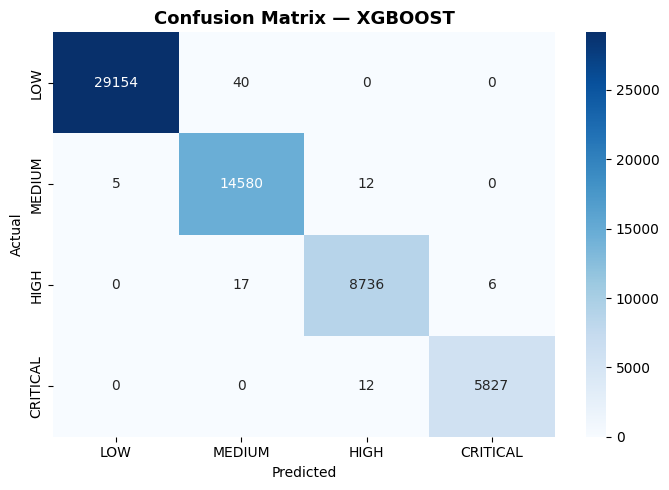

In [10]:
# ─────────────────────────────────────────────────────────────
# CELL 10 — Detailed Report for Winner
# ─────────────────────────────────────────────────────────────
print(f'\n── Classification Report: {WINNER.upper()} ─────────────────────────')
print(classification_report(
    all_results[WINNER]['yc_true'],
    all_results[WINNER]['yc_pred'],
    labels=RISK_LABEL_ORDER, zero_division=0
))

# Confusion matrix plot
cm = confusion_matrix(
    all_results[WINNER]['yc_true'],
    all_results[WINNER]['yc_pred'],
    labels=RISK_LABEL_ORDER
)
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=RISK_LABEL_ORDER, yticklabels=RISK_LABEL_ORDER, ax=ax)
ax.set_title(f'Confusion Matrix — {WINNER.upper()}', fontsize=13, fontweight='bold')
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

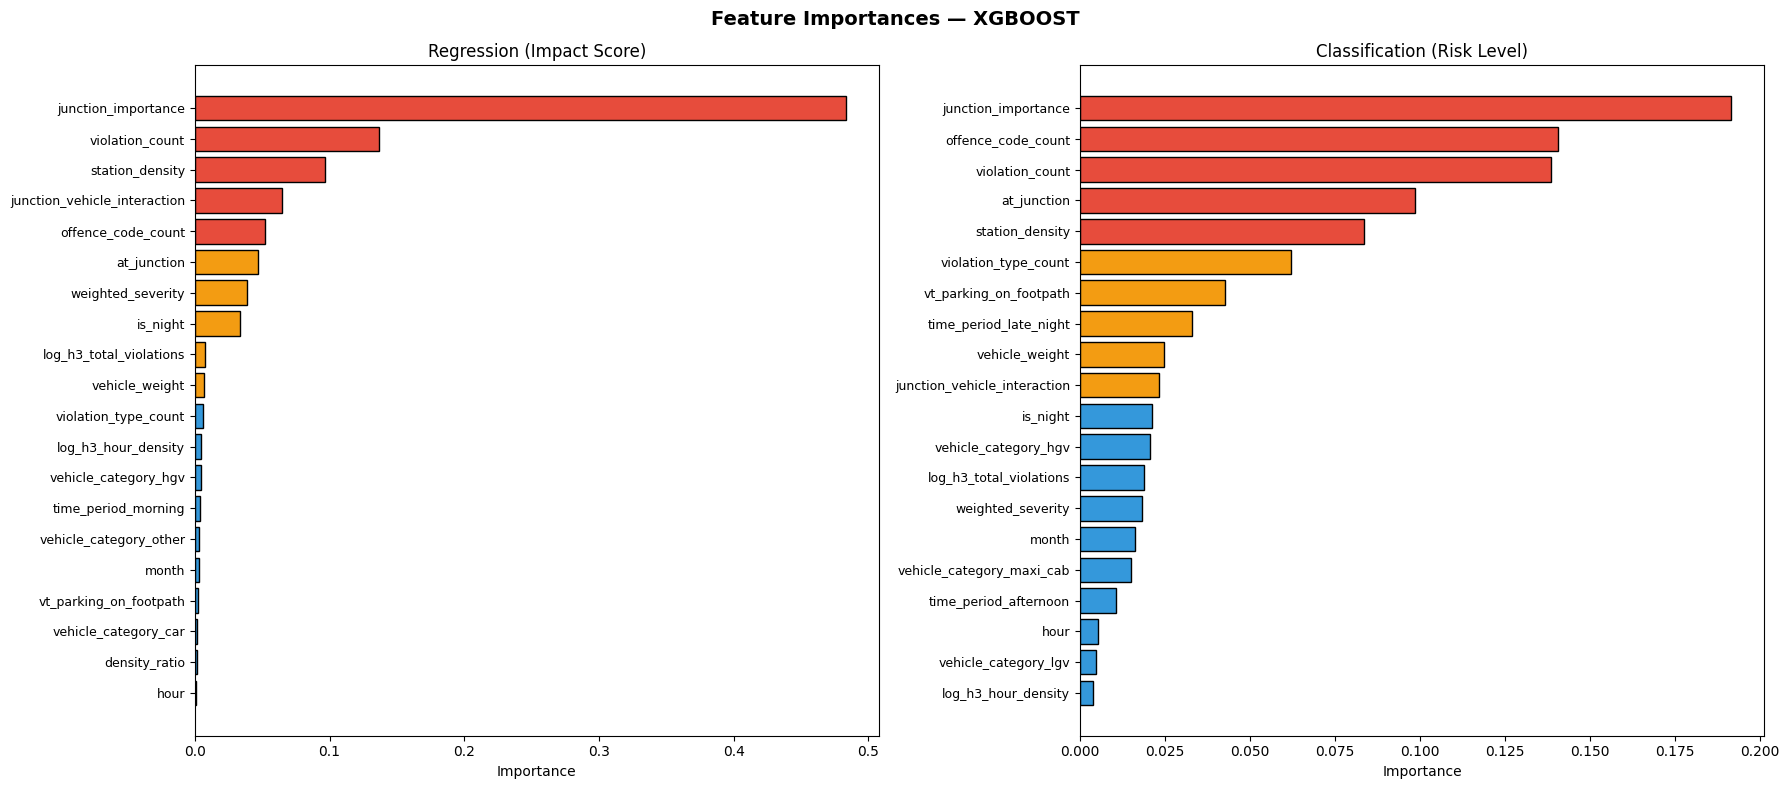

In [11]:
# ─────────────────────────────────────────────────────────────
# CELL 11 — Feature Importance Plot (FIXED)
# ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import pandas as pd

def get_feature_names(pipeline):
    preprocessor = pipeline.named_steps['preprocessor']
    cat_transformer = preprocessor.named_transformers_['cat']

    # Handle both cases: direct OneHotEncoder OR Pipeline
    if hasattr(cat_transformer, "named_steps"):
        ohe = cat_transformer.named_steps['ohe']
    else:
        ohe = cat_transformer

    cat_features = list(ohe.get_feature_names_out(CATEGORICAL_COLS))
    return ALL_NUMERIC + cat_features


fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.suptitle(f'Feature Importances — {WINNER.upper()}', fontsize=14, fontweight='bold')

for ax, (pipe, title) in zip(axes, [
    (trained_regs[WINNER],  'Regression (Impact Score)'),
    (trained_clses[WINNER], 'Classification (Risk Level)'),
]):
    # Get feature names
    feat_names = get_feature_names(pipe)

    # Get importances
    model = pipe.named_steps['model']

    # Some models may not have feature_importances_
    if not hasattr(model, "feature_importances_"):
        ax.set_title(f"{title} (No feature importance available)")
        continue

    importances = model.feature_importances_

    # Create dataframe
    feat_imp = pd.Series(importances, index=feat_names) \
                .sort_values(ascending=False) \
                .head(20)

    feat_imp_sorted = feat_imp.sort_values()

    # Color coding
    colors_bar = [
        '#e74c3c' if v > feat_imp_sorted.quantile(0.75) else
        '#f39c12' if v > feat_imp_sorted.quantile(0.5) else
        '#3498db'
        for v in feat_imp_sorted
    ]

    # Plot
    ax.barh(feat_imp_sorted.index, feat_imp_sorted.values,
            color=colors_bar, edgecolor='black')

    ax.set_title(title, fontsize=12)
    ax.set_xlabel('Importance')
    ax.tick_params(axis='y', labelsize=9)

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()

In [12]:
# ─────────────────────────────────────────────────────────────
# CELL 12 — Save Model Bundle
# ─────────────────────────────────────────────────────────────
model_bundle = {
    'model_name':              WINNER,
    'regression_pipeline':     trained_regs[WINNER],
    'classification_pipeline': trained_clses[WINNER],
    'label_encoder':           le,
    'feature_cols':            ALL_NUMERIC + CATEGORICAL_COLS,
    'risk_label_order':        RISK_LABEL_ORDER,
    'metrics': {
        'regression':     {'r2': all_results[WINNER]['r2'],
                           'mae': all_results[WINNER]['mae'],
                           'rmse': all_results[WINNER]['rmse']},
        'classification': {'accuracy': all_results[WINNER]['accuracy'],
                           'f1_weighted': all_results[WINNER]['f1']},
    },
    'model_version': '2.0.0',
}

joblib.dump(model_bundle, 'congestion_model.pkl')
print('✅ Saved: congestion_model.pkl')

size_mb = os.path.getsize('congestion_model.pkl') / 1024 / 1024
print(f'   File size : {size_mb:.1f} MB')
print(f'   Model used: {WINNER}')
print(f'   R²        : {all_results[WINNER]["r2"]:.4f}')
print(f'   Accuracy  : {all_results[WINNER]["accuracy"]:.4f}')
print(f'   F1 (w)    : {all_results[WINNER]["f1"]:.4f}')

✅ Saved: congestion_model.pkl
   File size : 5.4 MB
   Model used: xgboost
   R²        : 0.9997
   Accuracy  : 0.9984
   F1 (w)    : 0.9984


In [13]:
# ─────────────────────────────────────────────────────────────
# CELL 13 — Save Structured Model Artifacts
# ─────────────────────────────────────────────────────────────
import json, os, joblib
from datetime import datetime
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ── Create directory ──────────────────────────────────────────
OUTPUT_DIR = 'models/congestion'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Load trained bundle
bundle = joblib.load('congestion_model.pkl')
winner = bundle['model_name']
r      = all_results[winner]

# ─────────────────────────────────────────────────────────────
# 🔧 HELPER FUNCTION (FIXED)
# ─────────────────────────────────────────────────────────────
def get_top_features(pipe, top_n=10):
    preprocessor = pipe.named_steps['preprocessor']
    model = pipe.named_steps['model']

    cat_transformer = preprocessor.named_transformers_['cat']

    # Handle both cases safely
    if hasattr(cat_transformer, "named_steps"):
        ohe = cat_transformer.named_steps['ohe']
    else:
        ohe = cat_transformer

    feature_names = ALL_NUMERIC + list(ohe.get_feature_names_out(CATEGORICAL_COLS))

    importances = model.feature_importances_
    indices = importances.argsort()[::-1][:top_n]

    return [feature_names[i] for i in indices]

# ── 1. congestion_model.pkl ───────────────────────────────────
inference_bundle = {
    'regression_pipeline':     bundle['regression_pipeline'],
    'classification_pipeline': bundle['classification_pipeline'],
    'label_encoder':           bundle['label_encoder'],
    'risk_label_order':        bundle['risk_label_order'],
    'feature_cols':            bundle['feature_cols'],
    'model_version':           bundle['model_version'],
}
joblib.dump(inference_bundle, f'{OUTPUT_DIR}/congestion_model.pkl')
print('✅ congestion_model.pkl saved')

# ── 2. congestion_features.pkl ────────────────────────────────
feature_schema = {
    'all_features': bundle['feature_cols'],
    'numeric_features': ALL_NUMERIC,
    'categorical_features': CATEGORICAL_COLS,
    'violation_flags': VIOLATION_FLAGS,
    'engineered_features': ENGINEERED_COLS,
    'target_regression': 'congestion_impact_score',
    'target_classification': 'congestion_risk_level',
    'risk_labels': RISK_LABEL_ORDER,
}
joblib.dump(feature_schema, f'{OUTPUT_DIR}/congestion_features.pkl')
print('✅ congestion_features.pkl saved')

# ── 3. congestion_metrics.json ────────────────────────────────
yc_true = all_results[winner]['yc_true']
yc_pred = all_results[winner]['yc_pred']

cls_report = classification_report(
    yc_true, yc_pred, labels=RISK_LABEL_ORDER,
    output_dict=True, zero_division=0
)

cm = confusion_matrix(yc_true, yc_pred, labels=RISK_LABEL_ORDER).tolist()

yr_pred_test = trained_regs[winner].predict(X_test)

mae  = float(mean_absolute_error(yr_test, yr_pred_test))
rmse = float(mean_squared_error(yr_test, yr_pred_test) ** 0.5)
r2   = float(r2_score(yr_test, yr_pred_test))

metrics = {
    'regression': {
        'r2': round(r2, 4),
        'mae': round(mae, 4),
        'rmse': round(rmse, 4),
    },
    'classification': {
        'accuracy': round(float((np.array(yc_true) == np.array(yc_pred)).mean()), 4),
        'f1_weighted': round(r['f1'], 4),
        'confusion_matrix': cm
    }
}

with open(f'{OUTPUT_DIR}/congestion_metrics.json', 'w') as f:
    json.dump(metrics, f, indent=4)

print('✅ congestion_metrics.json saved')

# ── 4. congestion_metadata.json ───────────────────────────────
MODEL_TYPE_MAP = {
    'xgboost': ('XGBoostRegressor', 'XGBoostClassifier'),
    'random_forest': ('RandomForestRegressor', 'RandomForestClassifier'),
    'gradient_boosting': ('GradientBoostingRegressor', 'GradientBoostingClassifier'),
}

reg_type, cls_type = MODEL_TYPE_MAP[winner]

metadata = {
    'model_name': 'Congestion Impact Scorer',
    'model_version': '2.0.0',
    'created_at': datetime.utcnow().strftime('%Y-%m-%dT%H:%M:%SZ'),

    'outputs': {
        'regression': {
            'model_type': reg_type,
            'target': 'congestion_impact_score',
            'validation_r2': round(r2, 4),
            'validation_rmse': round(rmse, 4),
            'validation_mae': round(mae, 4),
        },
        'classification': {
            'model_type': cls_type,
            'target': 'congestion_risk_level',
            'accuracy': round(r['accuracy'], 4),
            'f1_weighted': round(r['f1'], 4),
        }
    },

    'features': bundle['feature_cols'],
    'top_features': get_top_features(trained_regs[winner]),

    'training': {
        'winner_model': winner,
        'train_size': len(X_train),
        'test_size': len(X_test),
    }
}

with open(f'{OUTPUT_DIR}/congestion_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=4)

print('✅ congestion_metadata.json saved')

# ── Summary ───────────────────────────────────────────────────
print('\n📁 Structure saved:')
for root, dirs, files_list in os.walk('models'):
    level = root.replace('models', '').count(os.sep)
    indent = '  ' * level
    print(f'{indent}{os.path.basename(root)}/')
    sub = '  ' * (level + 1)
    for fname in files_list:
        size = os.path.getsize(os.path.join(root, fname))
        size_str = f'{size/1024/1024:.1f} MB' if size > 1024*1024 else f'{size/1024:.1f} KB'
        print(f'{sub}{fname} ({size_str})')

✅ congestion_model.pkl saved
✅ congestion_features.pkl saved
✅ congestion_metrics.json saved
✅ congestion_metadata.json saved

📁 Structure saved:
models/
  congestion/
    congestion_model.pkl (5.4 MB)
    congestion_metadata.json (1.8 KB)
    congestion_metrics.json (0.6 KB)
    congestion_features.pkl (1.3 KB)


In [14]:
# ─────────────────────────────────────────────────────────────
# CELL 14 — Download models/congestion/ folder as ZIP
# ─────────────────────────────────────────────────────────────
import shutil
from google.colab import files

# Zip the congestion folder
shutil.make_archive('congestion_artifacts', 'zip', 'models', 'congestion')
print('📦 Zipped: congestion_artifacts.zip')

# Download the zip
files.download('congestion_artifacts.zip')
print('⬇️  Downloaded: congestion_artifacts.zip')
print('\nUnzip into your project as: models/congestion/')
print('  └── congestion_model.pkl')
print('  └── congestion_features.pkl')
print('  └── congestion_metrics.json')
print('  └── congestion_metadata.json')


📦 Zipped: congestion_artifacts.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

⬇️  Downloaded: congestion_artifacts.zip

Unzip into your project as: models/congestion/
  └── congestion_model.pkl
  └── congestion_features.pkl
  └── congestion_metrics.json
  └── congestion_metadata.json


In [15]:
# ─────────────────────────────────────────────────────────────
# CELL 15 — Sanity Check (predict 3 test cases)
# ─────────────────────────────────────────────────────────────
def predict_single(bundle, input_dict):
    df_in = pd.DataFrame([input_dict])
    df_in = engineer_features(df_in)
    X_in  = df_in[bundle['feature_cols']]
    score = float(bundle['regression_pipeline'].predict(X_in)[0])
    risk_enc   = bundle['classification_pipeline'].predict(X_in)[0]
    risk_label = bundle['label_encoder'].inverse_transform([risk_enc])[0]
    proba      = bundle['classification_pipeline'].predict_proba(X_in)[0]
    proba_dict = {l: round(float(p),4) for l,p in zip(bundle['risk_label_order'], proba)}
    return {'congestion_impact_score': round(score,4),
            'congestion_risk_level': risk_label,
            'risk_probabilities': proba_dict}

bundle = joblib.load('congestion_model.pkl')

TEST_CASES = [
    ('🔴 Junction + double parking (expect CRITICAL)', {
        'hour':18,'day_of_week':1,'month':11,'is_weekend':0,'time_period':'evening_peak',
        'at_junction':1,'h3_total_violations':14993,'h3_hour_density':2981,
        'vt_no_parking':0,'vt_wrong_parking':0,'vt_parking_in_a_main_road':0,
        'vt_parking_near_road_crossing':0,'vt_parking_on_footpath':0,'vt_double_parking':1,
        'vt_parking_near_bustop_school_hospital_etc':0,
        'vehicle_category':'car','vehicle_weight':1.0,
        'junction_importance':1.0,'station_density':0.19,'violation_count':3,'offence_code_count':3
    }),
    ('🟢 Early morning, two-wheeler (expect LOW)', {
        'hour':3,'day_of_week':2,'month':6,'is_weekend':0,'time_period':'early_morning',
        'at_junction':0,'h3_total_violations':50,'h3_hour_density':5,
        'vt_no_parking':1,'vt_wrong_parking':0,'vt_parking_in_a_main_road':0,
        'vt_parking_near_road_crossing':0,'vt_parking_on_footpath':0,'vt_double_parking':0,
        'vt_parking_near_bustop_school_hospital_etc':0,
        'vehicle_category':'two_wheeler','vehicle_weight':0.5,
        'junction_importance':0.0,'station_density':0.3,'violation_count':1,'offence_code_count':1
    }),
    ('🟡 Weekend midday, main road (expect MEDIUM/HIGH)', {
        'hour':13,'day_of_week':6,'month':3,'is_weekend':1,'time_period':'midday',
        'at_junction':0,'h3_total_violations':2079,'h3_hour_density':645,
        'vt_no_parking':0,'vt_wrong_parking':1,'vt_parking_in_a_main_road':1,
        'vt_parking_near_road_crossing':0,'vt_parking_on_footpath':0,'vt_double_parking':0,
        'vt_parking_near_bustop_school_hospital_etc':0,
        'vehicle_category':'two_wheeler','vehicle_weight':0.5,
        'junction_importance':0.0,'station_density':1.0,'violation_count':1,'offence_code_count':1
    }),
    ('🟢 Busy hour but sparse violations (expect still LOW - hour alone should not override sparsity)', {
        'hour':9,'day_of_week':2,'month':6,'is_weekend':0,'time_period':'morning_peak',
        'at_junction':0,'h3_total_violations':50,'h3_hour_density':5,
        'vt_no_parking':1,'vt_wrong_parking':0,'vt_parking_in_a_main_road':0,
        'vt_parking_near_road_crossing':0,'vt_parking_on_footpath':0,'vt_double_parking':0,
        'vt_parking_near_bustop_school_hospital_etc':0,
        'vehicle_category':'two_wheeler','vehicle_weight':0.5,
        'junction_importance':0.0,'station_density':0.3,'violation_count':1,'offence_code_count':1
    }),
]

print(f'Sanity check using: {bundle["model_name"].upper()}\n')
for label, feats in TEST_CASES:
    r = predict_single(bundle, feats)
    print(f'{label}')
    print(f'  Score : {r["congestion_impact_score"]}')
    print(f'  Level : {r["congestion_risk_level"]}')
    print(f'  Proba : {r["risk_probabilities"]}\n')

Sanity check using: XGBOOST

🔴 Junction + double parking (expect CRITICAL)
  Score : 11.26
  Level : CRITICAL
  Proba : {'LOW': 0.0, 'MEDIUM': 0.0, 'HIGH': 0.0013, 'CRITICAL': 0.9987}

🟢 Early morning, two-wheeler (expect LOW)
  Score : 2.7593
  Level : LOW
  Proba : {'LOW': 1.0, 'MEDIUM': 0.0, 'HIGH': 0.0, 'CRITICAL': 0.0}

🟡 Weekend midday, main road (expect MEDIUM/HIGH)
  Score : 4.2901
  Level : MEDIUM
  Proba : {'LOW': 0.0002, 'MEDIUM': 0.9984, 'HIGH': 0.0013, 'CRITICAL': 0.0}

🟢 Busy hour but sparse violations (expect still LOW - hour alone should not override sparsity)
  Score : 2.7596
  Level : LOW
  Proba : {'LOW': 1.0, 'MEDIUM': 0.0, 'HIGH': 0.0, 'CRITICAL': 0.0}

